In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import random
import numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import ImageFile
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

In [3]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def build_transforms(image_size=224):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(image_size),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    val_tf = transforms.Compose([
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return train_tf, val_tf

In [ ]:
class WrappedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = self.base.loader(path)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

In [ ]:
class FeatureExtractor(nn.Module):
    def __init__(self, model_name, pretrained=True, img_size=224, pool='avg'):
        super().__init__()
        self.net = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool=pool)

    def forward(self, x):
        return self.net(x)

In [ ]:
class Classifier(nn.Module):
    def __init__(self, feature_dims, num_classes, dropout=0.5, hidden_dim=512):
        super().__init__()
        total_dim = sum(feature_dims)
        self.mlp = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, features_list):
        x = torch.cat(features_list, dim=1)
        return self.mlp(x)

In [ ]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
def main():
    set_seed(42)
    device = get_device()
    print('Using device:', device)


    DATA_DIR = '/content/drive/MyDrive/FreshnessDetection/dataset'
    IMG_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 10
    NUM_CLASSES = 2


    train_tf, val_tf = build_transforms(image_size=IMG_SIZE)

    full_dataset = datasets.ImageFolder(DATA_DIR)
    labels = [s[1] for s in full_dataset.samples]
    labels_arr = np.array(labels)


    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_val_idx, test_idx = next(sss.split(np.zeros(len(labels_arr)), labels_arr))
    train_val_labels = labels_arr[train_val_idx]

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.111, random_state=42)
    train_idx_rel, val_idx_rel = next(sss2.split(np.zeros(len(train_val_labels)), train_val_labels))
    train_idx = train_val_idx[train_idx_rel]
    val_idx = train_val_idx[val_idx_rel]

    train_ds = WrappedDataset(full_dataset, train_idx, transform=train_tf)
    val_ds = WrappedDataset(full_dataset, val_idx, transform=val_tf)
    test_ds = WrappedDataset(full_dataset, test_idx, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    try:
        clip_model_name = 'vit_base_patch16_clip_224.openai'
        _ = timm.create_model(clip_model_name, pretrained=True, num_classes=0)
    except Exception:
        print("CLIP model not found in timm.")
        clip_model_name = None

    models_names = [
    ]

    if clip_model_name:
        models_names.append(clip_model_name)

    print(f"Using ensemble of {len(models_names)} feature extractors: {models_names}")

    extractors = [FeatureExtractor(m).to(device) for m in models_names]

    sample_input, _ = next(iter(train_loader))
    sample_input = sample_input.to(device)
    feature_dims = [ext(sample_input).shape[1] for ext in extractors]

    model = Classifier(feature_dims=feature_dims, num_classes=NUM_CLASSES).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print("\n Starting Training...\n")

    for epoch in range(EPOCHS):

        model.train()
        train_loss, val_loss = 0.0, 0.0
        all_train_preds, all_train_labels = [], []

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            features = [ext(imgs) for ext in extractors]
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_train_labels, all_train_preds)
        train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(
            all_train_labels, all_train_preds, average='binary'
        )


        model.eval()
        all_val_preds, all_val_labels = [], []

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
                imgs, labels = imgs.to(device), labels.to(device)
                features = [ext(imgs) for ext in extractors]
                outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
            all_val_labels, all_val_preds, average='binary'
        )


        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
        print(f"Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f}")


    torch.save(model.state_dict(), 'clip_model.pth')
    print("\n Training complete. Model saved as 'clip_model.pth'")

    return model, extractors, test_loader, device

In [ ]:
if __name__ == '__main__':
    model, extractors, test_loader, device = main()
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            features = [ext(imgs) for ext in extractors]
            outputs = model(features)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    specificity = tn / (tn + fp)
    roc_auc = roc_auc_score(all_labels, all_probs)
    mcc = matthews_corrcoef(all_labels, all_preds)

    print("\nFinal Test Metrics")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print(f"Matthews Corrcoef: {mcc:.4f}")
    print("Confusion Matrix:\n", cm)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Using ensemble of 1 feature extractors: ['vit_base_patch16_clip_224.openai']



 Starting Training...



...


Epoch 9/10
Train Loss: 0.1419 | Val Loss: 0.0438
Train Acc: 0.9435 | Val Acc: 0.9852
Train F1: 0.9466 | Val F1: 0.9859
Val Precision: 0.9927 | Val Recall: 0.9792


Epoch 10/10 [Train]:   0%|          | 0/659 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 10/10 [Val]:   0%|          | 0/83 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n


Epoch 10/10
Train Loss: 0.1423 | Val Loss: 0.0469
Train Acc: 0.9432 | Val Acc: 0.9821
Train F1: 0.9463 | Val F1: 0.9830
Val Precision: 0.9949 | Val Recall: 0.9713

 Training complete. Model saved as 'clip_model.pth'



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Final Test Metrics
Accuracy: 0.9799
Precision: 0.9948
Recall (Sensitivity): 0.9671
Specificity: 0.9943
F1-score: 0.9808
ROC AUC Score: 0.9985
Matthews Corrcoef: 0.9601
Confusion Matrix:
 [[1230    7]
 [  46 1351]]


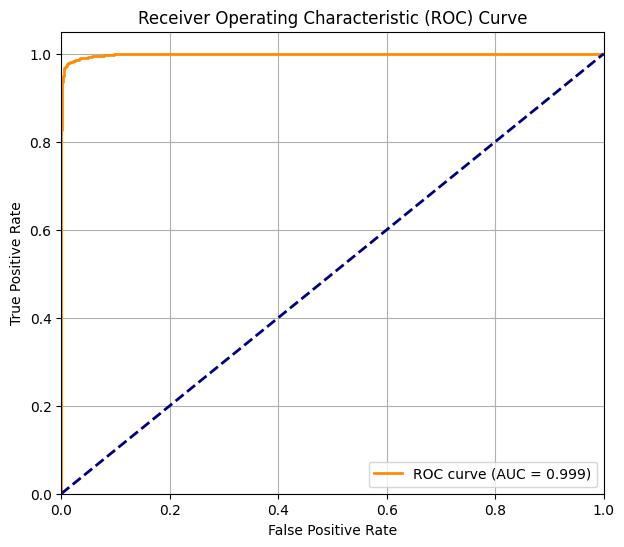

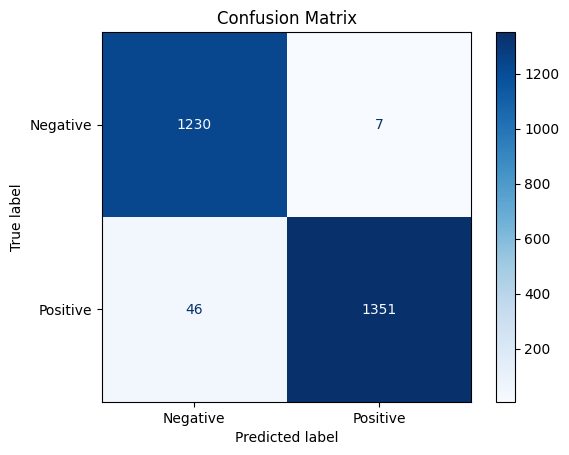

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()